# Creating map of LA County Restaurants


In [40]:
# imports
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Point

In [41]:
# Load working dataset
df = pd.read_csv("/Users/pdeguz01/Documents/git/Data/IDS705_Final/Working Dataset/MOST RECENT DATA/restauranthealthinspections2024_CensusSVIUSDA_halfmileradius.csv")

/var/folders/81/w_61xz297rv4ggdktb58tlxm0000gn/T/ipykernel_12080/2863018014.py:2: DtypeWarning: Columns (4,7,14,16,17,30,32,33,34,43,44) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/pdeguz01/Documents/git/Data/IDS705_Final/Working Dataset/MOST RECENT DATA/restauranthealthinspections2024_CensusSVIUSDA_halfmileradius.csv")


In [42]:
# Filter to just LA County
lacounty_df = df[df['County'] == "Los Angeles County"]

In [43]:
# Check if the object is a GeoDataFrame
if isinstance(lacounty_df, gpd.GeoDataFrame):
    print("The object is already a GeoDataFrame.")
else:
    print("The object is NOT a GeoDataFrame.")

The object is NOT a GeoDataFrame.


In [44]:
# Load LA County Shapefile
# Define the path to your shapefile
shapefile_path = '/Users/pdeguz01/Documents/git/Data/IDS705_Final/Working Dataset/MOST RECENT DATA/County_Boundary/County_Boundary.shp'

# Load the shapefile into a GeoDataFrame
la_county_gdf = gpd.read_file(shapefile_path)

# Check the first few rows of the GeoDataFrame to ensure it loaded correctly
print(la_county_gdf.head())

   OBJECTID  CITY  CITY_ID       CITY_TYPE       CITY_NAME      CITY_LABEL  \
0         1   250       31  Unincorporated  Unincorporated  Unincorporated   
1         2   250       31  Unincorporated  Unincorporated  Unincorporated   
2         3   250       31  Unincorporated  Unincorporated  Unincorporated   
3         4   250       31  Unincorporated  Unincorporated  Unincorporated   
4         5   250       31  Unincorporated  Unincorporated  Unincorporated   

   COLOR_CODE  ABBR  CITY_NO DESCRIPTN               URL       PHONE  \
0           1  UNIN        0     UNINC  www.lacounty.gov  2139744321   
1           1  UNIN        0     UNINC  www.lacounty.gov  2139744321   
2           1  UNIN        0     UNINC  www.lacounty.gov  2139744321   
3           1  UNIN        0     UNINC  www.lacounty.gov  2139744321   
4           1  UNIN        0     UNINC  www.lacounty.gov  2139744321   

   OF_AREA_SM FEAT_TYPE COMMENT  SUB_TYPE COLOR  \
0           0      Land    None         0     1

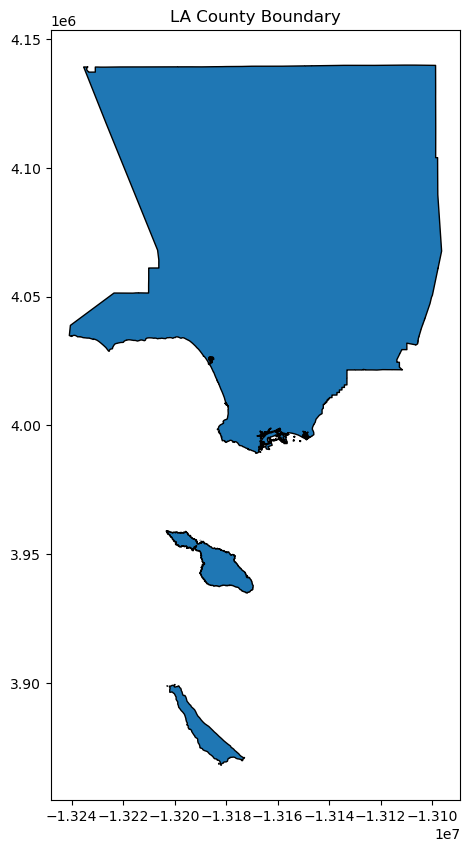

In [45]:
# Plot the LA County boundary
la_county_gdf.plot(figsize=(10, 10), edgecolor='black')
plt.title("LA County Boundary")
plt.show()

In [46]:
lacountydf_cleaned = lacounty_df.dropna(subset=['Latitude', 'Longitude'])


In [47]:
# Convert the DataFrame to GeoDataFrame with Point geometry
geometry = [Point(lon, lat) for lon, lat in zip(lacountydf_cleaned['Longitude'], lacountydf_cleaned['Latitude'])]
gdf = gpd.GeoDataFrame(lacountydf_cleaned, geometry=geometry)


In [48]:
if la_county_gdf.crs != gdf.crs:
    gdf = gdf.set_crs(la_county_gdf.crs, allow_override=True)

In [49]:
print("LA County CRS:", la_county_gdf.crs)
print("Restaurant CRS:", gdf.crs)

LA County CRS: EPSG:3857
Restaurant CRS: EPSG:3857


In [50]:
la_county_gdf = la_county_gdf.to_crs(epsg=4326)
gdf = gdf.set_crs(epsg=4326, allow_override=True)


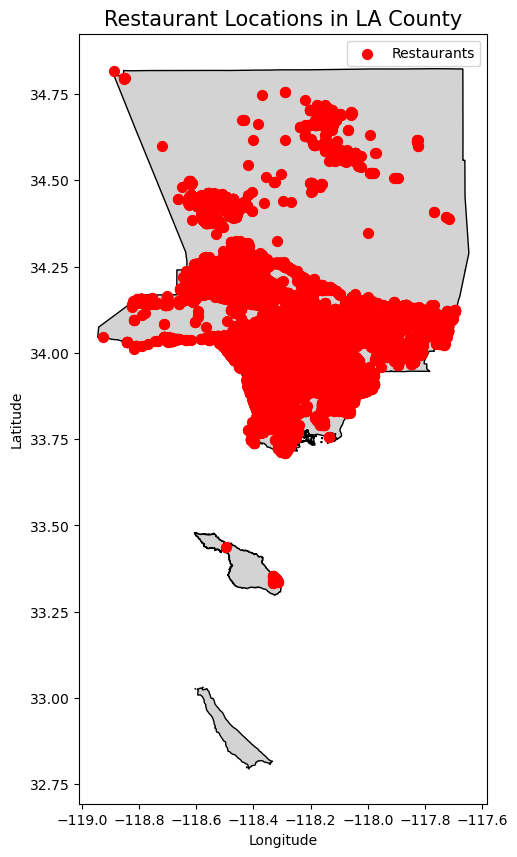

In [52]:
# If they don't match, reproject the restaurant data to match LA County CRS
if la_county_gdf.crs != gdf.crs:
    gdf = gdf.set_crs(la_county_gdf.crs, allow_override=True)

# Plotting
fig, ax = plt.subplots(figsize=(10, 10))

# Plot LA County boundary (background)
la_county_gdf.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=1)

# Plot the restaurant locations on top of LA County boundary
gdf.plot(ax=ax, marker='o', color='red', markersize=50, label="Restaurants")

# Customize the plot with titles and labels
plt.title("Restaurant Locations in LA County", fontsize=15)
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Add a legend for the restaurants
plt.legend()

# Save the figure as a PNG image (optional)
plt.savefig("restaurant_map_with_la_boundary.png", format="png", dpi=300)

# Display the plot
plt.show()

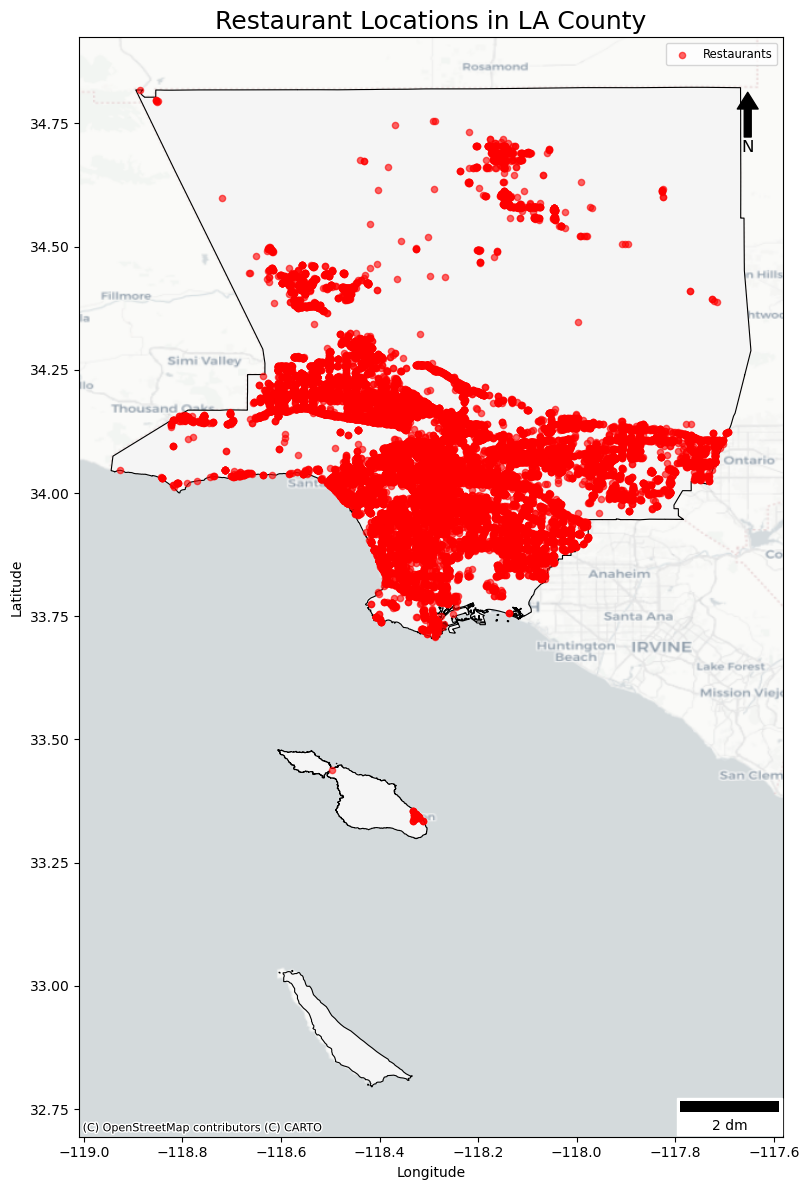

In [55]:
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib_scalebar.scalebar import ScaleBar

# Plotting
fig, ax = plt.subplots(figsize=(12, 12))
la_county_gdf.plot(ax=ax, color='whitesmoke', edgecolor='black', linewidth=0.8)
gdf.plot(ax=ax, marker='o', color='red', markersize=20, alpha=0.6, label="Restaurants")

# Use a currently working basemap
ctx.add_basemap(ax, crs=la_county_gdf.crs.to_string(), source=ctx.providers.CartoDB.Positron)

ax.set_aspect('equal')
plt.title("Restaurant Locations in LA County", fontsize=18)
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.legend(loc='upper right', fontsize='small', frameon=True)

scalebar = ScaleBar(1, location='lower right') # Add a scale bar
ax.add_artist(scalebar)

ax.annotate('N', xy=(0.95, 0.95), xytext=(0.95, 0.90),
            arrowprops=dict(facecolor='black', width=5, headwidth=15),
            ha='center', va='center', fontsize=12,
            xycoords=ax.transAxes)

plt.tight_layout()
plt.savefig("restaurant_map_with_la_boundary_better.png", dpi=300)
plt.show()

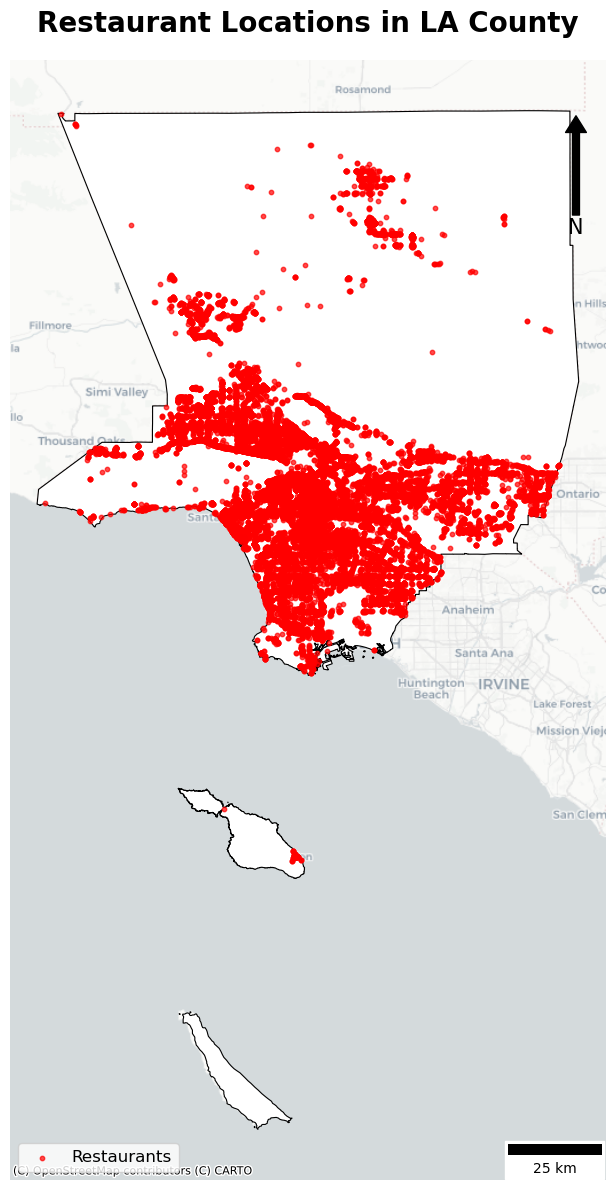

In [56]:
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib_scalebar.scalebar import ScaleBar

# If your data is in degrees (EPSG:4326), reproject to Web Mercator for basemaps
gdf = gdf.to_crs(epsg=3857)
la_county_gdf = la_county_gdf.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(12, 12))

# Plot LA County boundary
la_county_gdf.plot(ax=ax, color='white', edgecolor='black', linewidth=0.8)

# Plot restaurants
gdf.plot(ax=ax, marker='o', color='red', markersize=10, alpha=0.7, label="Restaurants")

# Add a light basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# Prettify
ax.set_axis_off()  # Remove x and y labels, ticks
plt.title("Restaurant Locations in LA County", fontsize=20, fontweight='bold', pad=20)

# Legend
plt.legend(loc='lower left', fontsize=12, frameon=True)

# Add scalebar
scalebar = ScaleBar(1, units='m', location='lower right')  # 1 = meter in Web Mercator
ax.add_artist(scalebar)

# North arrow
ax.annotate('N', xy=(0.95, 0.95), xytext=(0.95, 0.85),
            arrowprops=dict(facecolor='black', width=5, headwidth=15),
            ha='center', va='center', fontsize=15,
            xycoords=ax.transAxes)

plt.tight_layout()
plt.savefig("pretty_restaurant_map.png", dpi=300)
plt.show()


In [57]:
# Sort geometries by area and keep the largest (mainland)
la_county_mainland = la_county_gdf.copy()

# If it's a MultiPolygon (common), explode into separate parts
if la_county_mainland.geom_type.iloc[0] == 'MultiPolygon':
    la_county_mainland = la_county_mainland.explode(index_parts=False)

# Keep only the largest polygon (mainland)
la_county_mainland['area'] = la_county_mainland.area
la_county_mainland = la_county_mainland.sort_values(by='area', ascending=False).iloc[[0]]

# Drop the 'area' column (cleanup)
la_county_mainland = la_county_mainland.drop(columns='area')


In [60]:
# Ensure same CRS (already reprojected to EPSG:3857 earlier)
gdf = gdf.to_crs(la_county_mainland.crs)

# Keep only restaurants within mainland LA boundary
gdf_inside_mainland = gdf[gdf.within(la_county_mainland.geometry.values[0])]


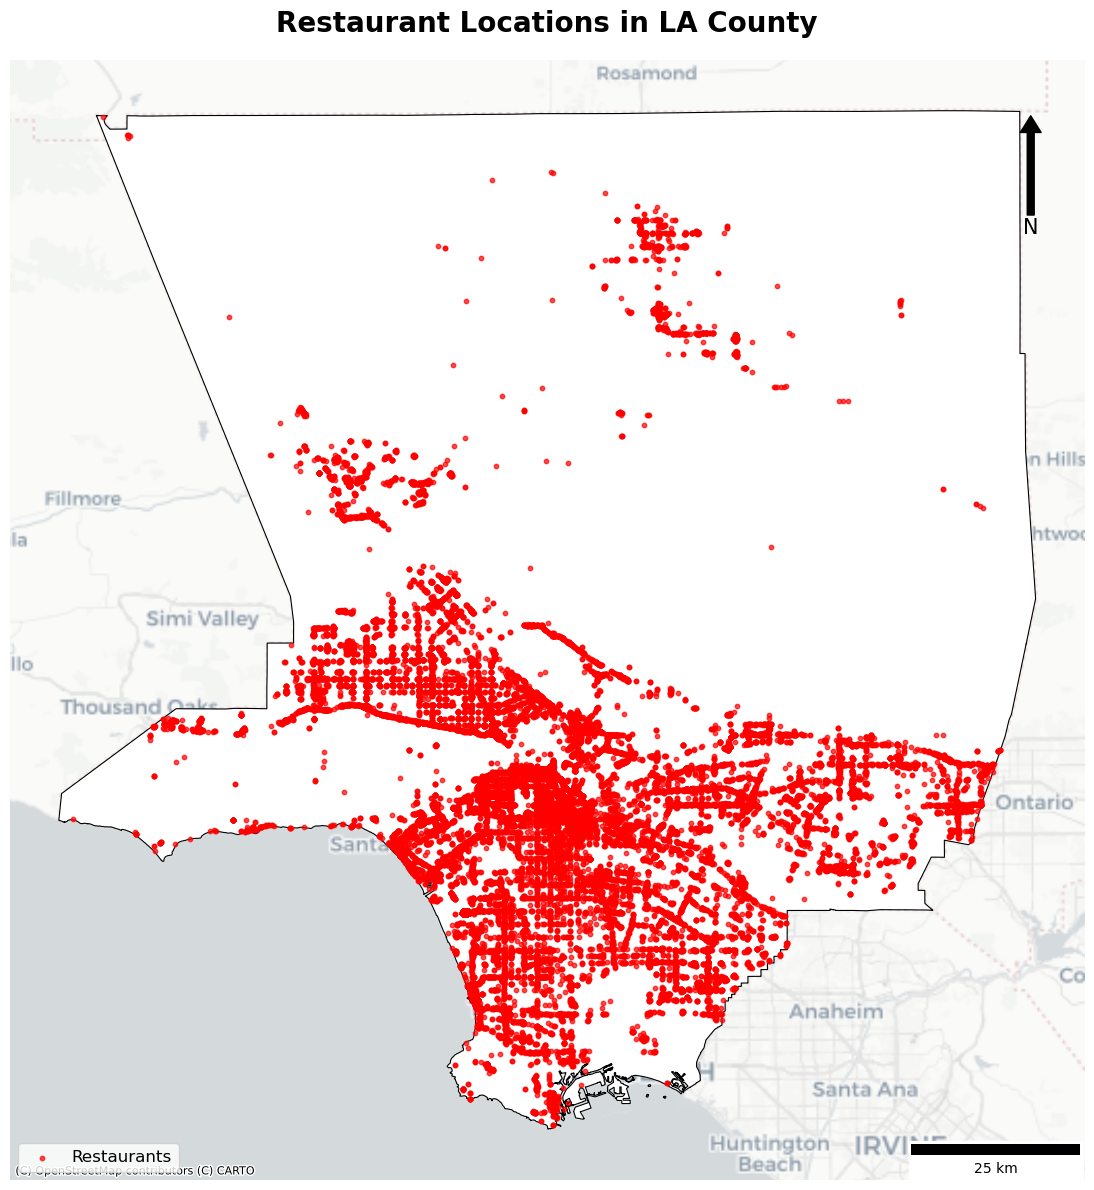

In [62]:
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib_scalebar.scalebar import ScaleBar

# (Assuming you already reprojected and exploded mainland as before)

# Filter restaurants
gdf_inside_mainland = gdf[gdf.within(la_county_mainland.geometry.values[0])]

# Plotting
fig, ax = plt.subplots(figsize=(12, 12))

# Plot mainland boundary
la_county_mainland.plot(ax=ax, color='white', edgecolor='black', linewidth=0.8)

# Plot only restaurants inside mainland
gdf_inside_mainland.plot(ax=ax, marker='o', color='red', markersize=10, alpha=0.7, label="Restaurants")

# Add a basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# Beautify the map
ax.set_axis_off()
plt.title("Restaurant Locations in LA County", fontsize=20, fontweight='bold', pad=20)
plt.legend(loc='lower left', fontsize=12, frameon=True)

# Add scalebar
scalebar = ScaleBar(1, units='m', location='lower right')
ax.add_artist(scalebar)

# Add North arrow
ax.annotate('N', xy=(0.95, 0.95), xytext=(0.95, 0.85),
            arrowprops=dict(facecolor='black', width=5, headwidth=15),
            ha='center', va='center', fontsize=15,
            xycoords=ax.transAxes)

plt.tight_layout()
plt.savefig("pretty_restaurant_map_mainland_only.png", dpi=300)
plt.show()

